# Bank Marketing: Predicting Term Deposit Subscriptions

**Digica Academy Data Science Bootcamp: Final Project**
Shakira Maharani Setya (group project with Dewi Kurnia)

## Objective

A Portuguese bank ran direct-marketing phone campaigns to sell term deposits. Calling every customer is expensive, so the bank wants to know:

1. **Which customer segments are most likely to subscribe?** (exploratory analysis)
2. **Can we predict, before calling, whether a customer will subscribe?** (classification model)

The answers help the marketing team prioritise who to call and when.

## Contents
1. Setup and data loading
2. Data quality checks
3. Exploratory data analysis
4. Preprocessing
5. Modelling: Logistic Regression vs Random Forest
6. Conclusions and recommendations

## 1. Setup and data loading

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, ConfusionMatrixDisplay)

sns.set_theme(style="whitegrid")
COLORS = {"no": "#b0b7bf", "yes": "#3a9947"}

In [2]:
df = pd.read_csv("marketing-dataset.csv")
print(df.shape)
df.head()

(11162, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


Each row is one customer contacted during the campaign. Key columns:

| Column | Meaning |
|---|---|
| `age`, `job`, `marital`, `education` | Customer demographics |
| `balance` | Average yearly account balance (EUR) |
| `housing`, `loan`, `default` | Whether the customer has a housing loan, personal loan, or credit in default |
| `contact`, `day`, `month` | How and when the customer was last contacted |
| `duration` | Length of the last call in seconds |
| `campaign` | Number of contacts during this campaign |
| `pdays`, `previous`, `poutcome` | Contact history and outcome from the previous campaign |
| `deposit` | **Target:** did the customer subscribe? |

## 2. Data quality checks

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        11162 non-null  int64
 1   job        11162 non-null  str  
 2   marital    11162 non-null  str  
 3   education  11162 non-null  str  
 4   default    11162 non-null  str  
 5   balance    11162 non-null  int64
 6   housing    11162 non-null  str  
 7   loan       11162 non-null  str  
 8   contact    11162 non-null  str  
 9   day        11162 non-null  int64
 10  month      11162 non-null  str  
 11  duration   11162 non-null  int64
 12  campaign   11162 non-null  int64
 13  pdays      11162 non-null  int64
 14  previous   11162 non-null  int64
 15  poutcome   11162 non-null  str  
 16  deposit    11162 non-null  str  
dtypes: int64(7), str(10)
memory usage: 1.4 MB


In [4]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Missing values: 0
Duplicate rows: 0


In [5]:
df.describe().round(1)

,age,balance,day,duration,campaign,pdays,previous
count,11162.0,11162.0,11162.0,11162.0,11162.0,11162.0,11162.0
mean,41.2,1528.5,15.7,372.0,2.5,51.3,0.8
std,11.9,3225.4,8.4,347.1,2.7,108.8,2.3
min,18.0,-6847.0,1.0,2.0,1.0,-1.0,0.0
25%,32.0,122.0,8.0,138.0,1.0,-1.0,0.0
50%,39.0,550.0,15.0,255.0,2.0,-1.0,0.0
75%,49.0,1708.0,22.0,496.0,3.0,20.8,1.0
max,95.0,81204.0,31.0,3881.0,63.0,854.0,58.0


**Findings:**
- 11,162 rows, 17 columns, with **no missing values and no duplicates**.
- Some categorical columns use `"unknown"` instead of a blank (e.g. `contact`, `education`, `poutcome`). These are kept as their own category, since "unknown" turns out to carry signal.
- `balance` ranges from -6,847 to 81,204, so it's heavily right-skewed with a few very large accounts.
- `pdays = -1` means the customer was **not contacted** in a previous campaign.

## 3. Exploratory data analysis

### 3.1 Target variable

deposit
no     52.6
yes    47.4
Name: proportion, dtype: float64


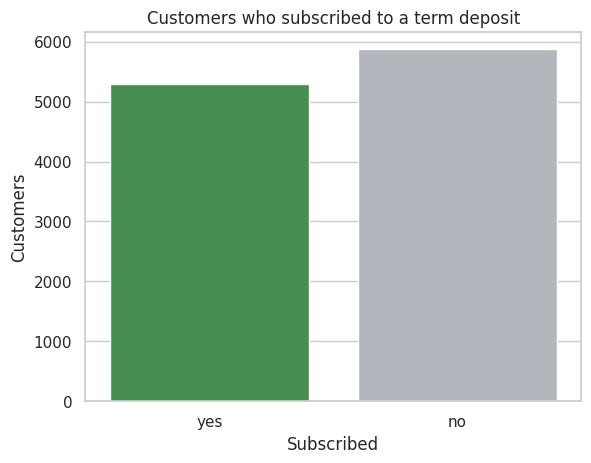

In [6]:
print(df["deposit"].value_counts(normalize=True).mul(100).round(1))

ax = sns.countplot(data=df, x="deposit", hue="deposit", palette=COLORS, legend=False)
ax.set(title="Customers who subscribed to a term deposit", xlabel="Subscribed", ylabel="Customers")
plt.show()

The classes are **roughly balanced** (53% no, 47% yes), so accuracy is a fair metric and no resampling is needed.

### 3.2 Subscription rate by customer segment

Rather than raw counts, the charts below show the **subscription rate** for each group, which directly answers "who is most likely to say yes?". The dashed line is the overall average (47%).

In [7]:
df["subscribed"] = (df["deposit"] == "yes").astype(int)
OVERALL_RATE = df["subscribed"].mean()

def plot_rate(column, ax, order=None, title=None):
    """Bar chart of subscription rate per category, with group sizes annotated."""
    stats = df.groupby(column, observed=True)["subscribed"].agg(["mean", "size"])
    stats = stats.loc[order] if order is not None else stats.sort_values("mean", ascending=False)
    bars = ax.bar(stats.index.astype(str), stats["mean"] * 100, color="#3a9947")
    ax.axhline(OVERALL_RATE * 100, ls="--", color="grey", lw=1)
    for bar, n in zip(bars, stats["size"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, f"n={n}",
                ha="center", fontsize=8, color="dimgrey")
    ax.set(title=title or column, ylabel="Subscription rate (%)", ylim=(0, 105))
    ax.tick_params(axis="x", rotation=45)

#### Demographics

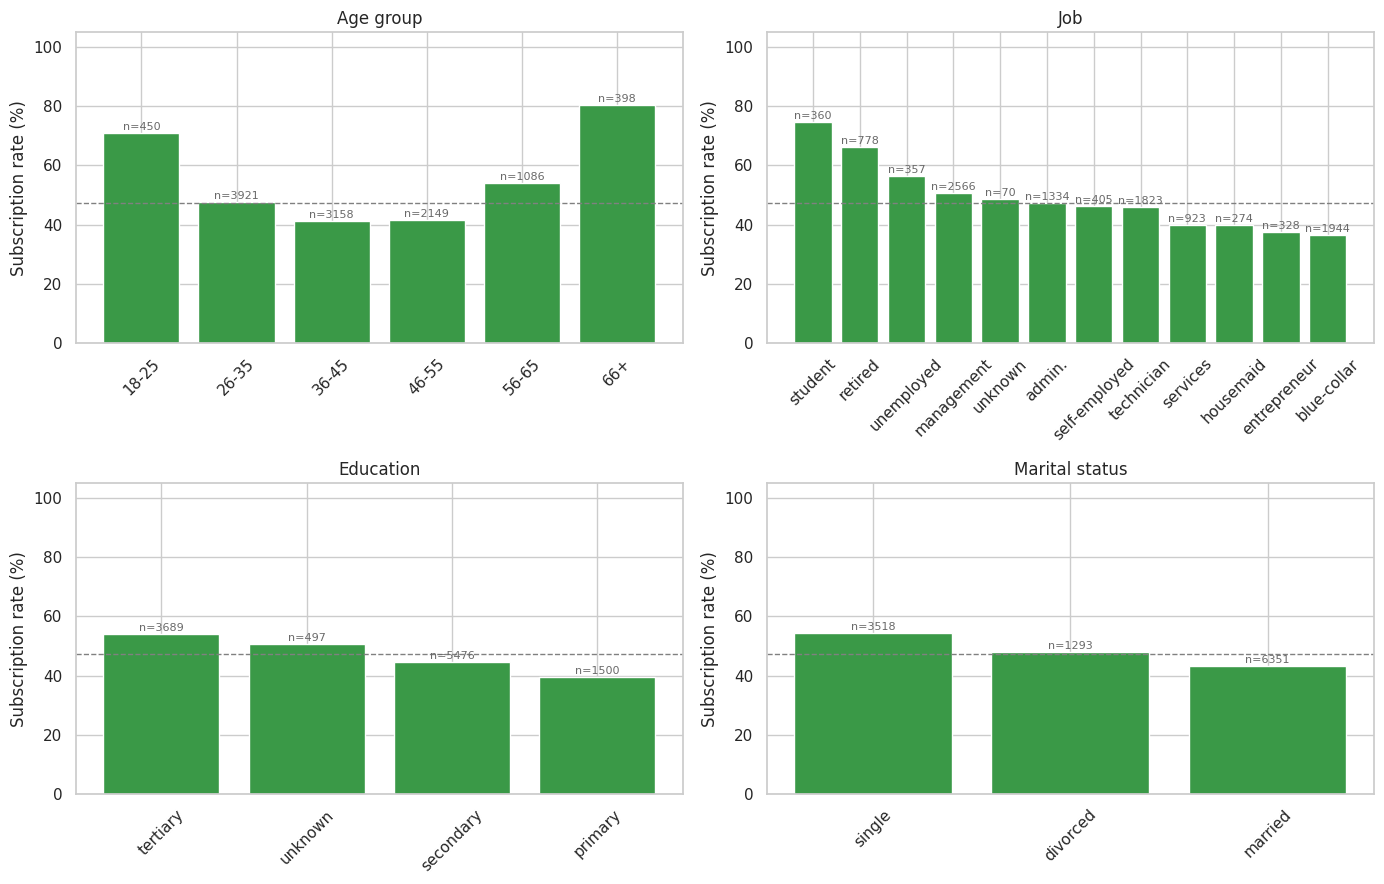

In [8]:
df["age_group"] = pd.cut(df["age"], bins=[17, 25, 35, 45, 55, 65, 100],
                         labels=["18-25", "26-35", "36-45", "46-55", "56-65", "66+"])

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
plot_rate("age_group", axes[0, 0], order=["18-25", "26-35", "36-45", "46-55", "56-65", "66+"], title="Age group")
plot_rate("job", axes[0, 1], title="Job")
plot_rate("education", axes[1, 0], title="Education")
plot_rate("marital", axes[1, 1], title="Marital status")
plt.tight_layout()
plt.show()

**Insights:**
- Age shows a **U-shape**: the youngest (18–25, 71%) and oldest (66+, 80%) customers subscribe far more than middle-aged customers (~41% for 36–55).
- The same pattern shows up in job: **students (75%) and retirees (66%)** lead, while blue-collar workers (36%) and entrepreneurs (38%) are least likely.
- Tertiary-educated (54%) and single (54%) customers are above average.

#### Financial situation

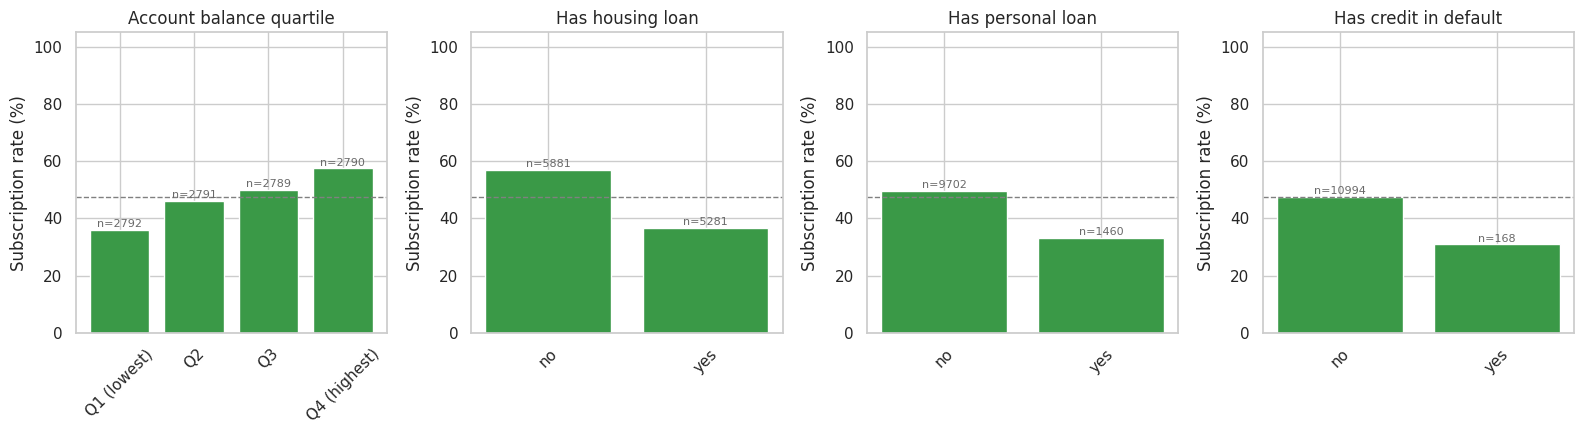

In [9]:
df["balance_quartile"] = pd.qcut(df["balance"], 4, labels=["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"])

fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
plot_rate("balance_quartile", axes[0], order=["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"], title="Account balance quartile")
plot_rate("housing", axes[1], order=["no", "yes"], title="Has housing loan")
plot_rate("loan", axes[2], order=["no", "yes"], title="Has personal loan")
plot_rate("default", axes[3], order=["no", "yes"], title="Has credit in default")
plt.tight_layout()
plt.show()

**Insights:**
- Subscription rises steadily with balance, from **36% in the lowest quartile to 58% in the highest**.
- Customers **without existing debt** are much more likely to subscribe: no housing loan 57% vs 37% with one; no personal loan 50% vs 33%.
- This makes sense: customers with spare money and no repayments are better placed to lock funds into a deposit.

#### Campaign and contact history

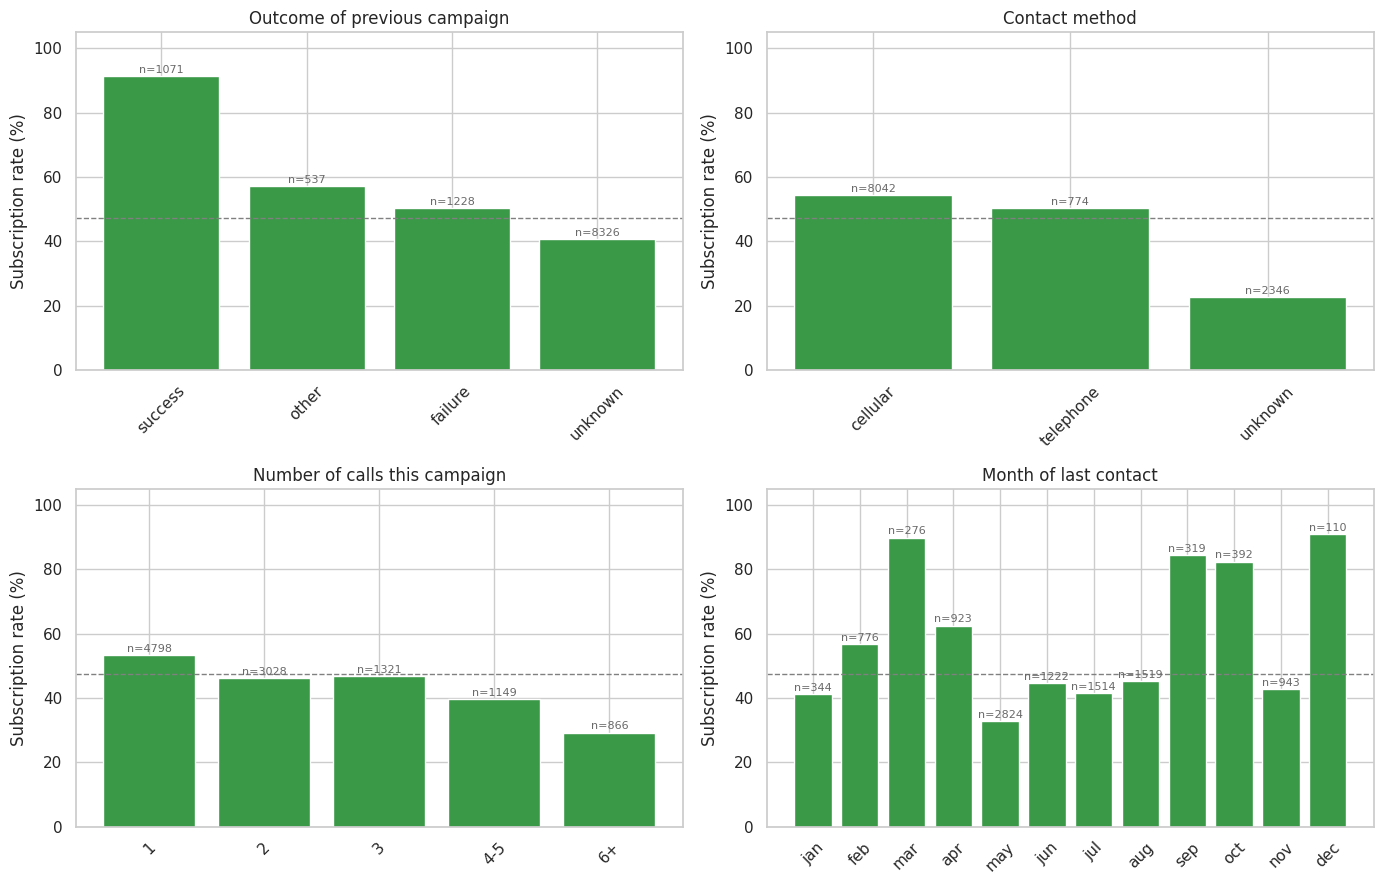

In [10]:
df["campaign_group"] = pd.cut(df["campaign"], bins=[0, 1, 2, 3, 5, 100], labels=["1", "2", "3", "4-5", "6+"])

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
plot_rate("poutcome", axes[0, 0], title="Outcome of previous campaign")
plot_rate("contact", axes[0, 1], title="Contact method")
plot_rate("campaign_group", axes[1, 0], order=["1", "2", "3", "4-5", "6+"], title="Number of calls this campaign")
plot_rate("month", axes[1, 1],
          order=["jan", "feb", "mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"],
          title="Month of last contact")
plt.tight_layout()
plt.show()

**Insights:**
- **Past success is the strongest single signal:** 91% of customers who subscribed in the previous campaign subscribed again.
- **More calls do not help.** The rate drops from 53% after one call to 29% after six or more, so repeated calling has diminishing returns.
- Customers with an `unknown` contact method convert at only 23%, which may reflect outdated contact details.
- **May** had by far the most calls (2,824) but the **lowest** rate (33%), whereas March, September, October and December convert above 80% on small volumes. Call volume and conversion are clearly mismatched.

### 3.3 Correlation between numeric features

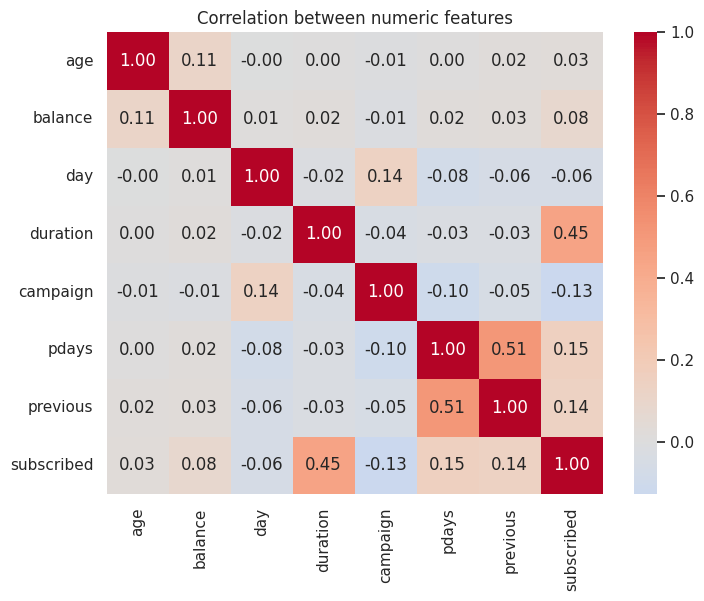

In [11]:
numeric_cols = ["age", "balance", "day", "duration", "campaign", "pdays", "previous", "subscribed"]
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation between numeric features")
plt.show()

`duration` has by far the strongest correlation with subscribing (0.45). However, **call duration is only known after the call has ended**, so it can't be used to decide who to call. This is addressed in the next section.

The other numeric features have weak linear correlations individually, which suggests a non-linear model may capture more (e.g. the U-shaped age pattern above).

## 4. Preprocessing

Three decisions:

1. **Drop `duration` (data leakage).** A long call usually means the customer was already interested, but we only learn the duration once the call is over. Including it would inflate the scores while making the model useless for planning who to call. Section 5.4 shows how much it inflates the results.
2. **One-hot encode** categorical columns.
3. **Stratified 80/20 train-test split**, so both sets keep the same yes/no ratio.

The helper columns created for EDA (`age_group`, `balance_quartile`, etc.) are excluded, since the model uses the original raw values.

In [12]:
FEATURES = ["age", "job", "marital", "education", "default", "balance", "housing", "loan",
            "contact", "day", "month", "campaign", "pdays", "previous", "poutcome"]

X = pd.get_dummies(df[FEATURES], drop_first=True)
y = df["subscribed"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (8929, 41) | Test: (2233, 41)


## 5. Modelling

Two models are compared:
- **Logistic Regression:** a simple, interpretable baseline. Features are standardised first, since it's sensitive to scale.
- **Random Forest:** an ensemble of decision trees that can capture non-linear patterns and interactions.

In [13]:
models = {
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
}

def evaluate(model, X_tr, X_te):
    model.fit(X_tr, y_train)
    pred = model.predict(X_te)
    prob = model.predict_proba(X_te)[:, 1]
    return {
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC AUC": roc_auc_score(y_test, prob),
    }

results = pd.DataFrame({name: evaluate(m, X_train, X_test) for name, m in models.items()}).T
results.round(3)

,Accuracy,Precision,Recall,F1,ROC AUC
Logistic Regression,0.695,0.732,0.561,0.636,0.758
Random Forest,0.724,0.748,0.629,0.684,0.782


### 5.1 Results

**Random Forest performs better on every metric**, including higher recall (finds more of the actual subscribers) and higher ROC AUC (better at ranking customers from most to least likely).

Metric meanings, in business terms:
- **Precision:** of the customers the model says to call, how many actually subscribe.
- **Recall:** of all customers who would subscribe, how many the model finds.
- **ROC AUC:** how well the model ranks customers. 0.5 is random guessing, 1.0 is perfect.

### 5.2 Confusion matrices

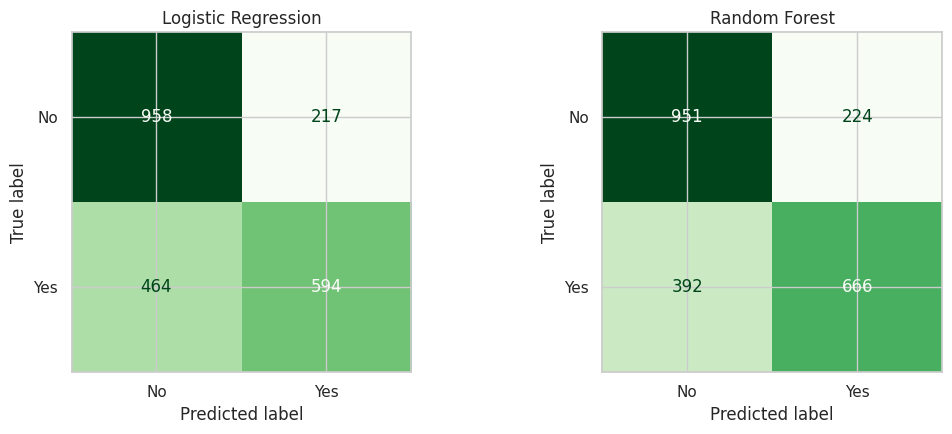

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (name, model) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, display_labels=["No", "Yes"],
                                          cmap="Greens", colorbar=False, ax=ax)
    ax.set_title(name)
plt.tight_layout()
plt.show()

### 5.3 What drives the Random Forest's predictions?

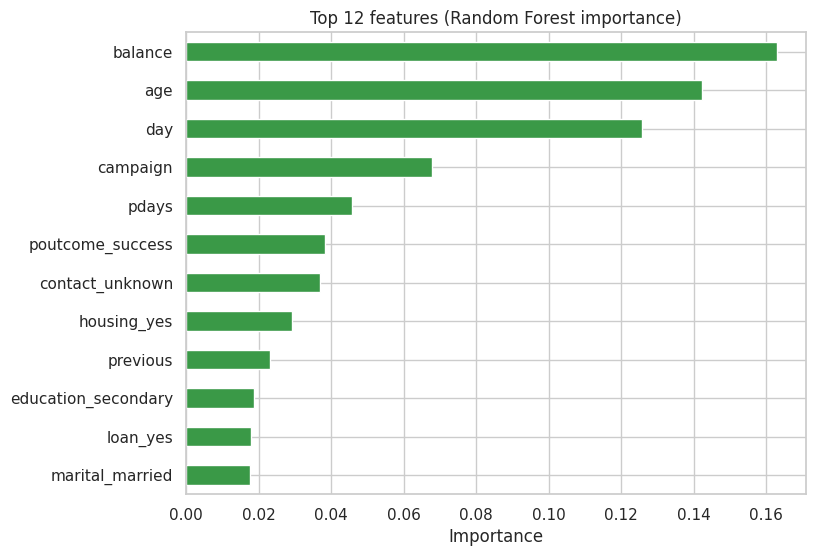

In [15]:
rf = models["Random Forest"]
importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values().tail(12)

plt.figure(figsize=(8, 6))
importance.plot.barh(color="#3a9947")
plt.title("Top 12 features (Random Forest importance)")
plt.xlabel("Importance")
plt.show()

The most important features are **balance, age and day of the month**, followed by the number of calls this campaign and previous-campaign history (`pdays`, `poutcome_success`). This lines up with the EDA: financial capacity, life stage, past success and call fatigue all matter.

### 5.4 Why dropping `duration` matters

For comparison, here is the same Random Forest trained **with** `duration` included.

In [16]:
X_leaky = pd.get_dummies(df[FEATURES + ["duration"]], drop_first=True)
X_train_l, X_test_l = X_leaky.loc[X_train.index], X_leaky.loc[X_test.index]

leaky = evaluate(RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1), X_train_l, X_test_l)
comparison = pd.DataFrame({
    "Without duration (realistic)": results.loc["Random Forest"],
    "With duration (leaky)": pd.Series(leaky),
})
comparison.round(3)

,Without duration (realistic),With duration (leaky)
Accuracy,0.724,0.861
Precision,0.748,0.829
Recall,0.629,0.890
F1,0.684,0.859
ROC AUC,0.782,0.921


Including `duration` raises accuracy by roughly 14 percentage points, but that model can only "predict" after the call has already happened, so it's no use for deciding who to call. **The model without `duration` is the honest estimate** of how well the bank can target customers in advance.

## 6. Conclusions and recommendations

### Key findings
- **Who subscribes:** students and retirees (the youngest and oldest age groups), customers with higher balances, and customers without housing or personal loans.
- **Past success predicts future success:** 91% of previous subscribers subscribed again.
- **Calling more doesn't help:** conversion falls from 53% after one call to 29% after six or more.
- **Timing matters:** May had the highest call volume but the lowest conversion rate.

### Model
A **Random Forest** using only information available *before* a call ranks customers with a ROC AUC of about 0.78, clearly better than random calling and better than the Logistic Regression baseline.

### Recommendations for the marketing team
1. **Prioritise previous subscribers** and customers with higher balances and no existing loans.
2. **Target students and retirees** with tailored messaging.
3. **Cap calls at around 3 per customer**, since extra calls cost money with little return.
4. **Rebalance call volume away from May** towards months with better conversion, and test whether those higher rates hold at larger volumes.
5. **Clean up contact details** for customers with an `unknown` contact method.

### Limitations and next steps
- The data comes from a single bank, so results may not generalise.
- Strong rates in some months (e.g. December) are based on small samples.
- Next steps: tune hyperparameters, try gradient boosting models, and pick a probability threshold based on the actual cost of a call vs the value of a deposit.